# 1. K-NN classifier

**Question** How does the k-nn algorithm work?

**Question** What are the parameters we need to choose to classify with k-NN? How can we choose them

**Question** What are the advantages and disadvantages of this algorithm? For which kind of dataset it would be appropriate and for which datasets it wouldn't?

**Question** How can we deal with nominal values in distance measurement?


In further part of the laboratory, we will perform a preprocessing of the data and a classification of a set of biomedical voice measurements. Some of them has been recorded for people with Parkinson's desease.

More about the dataset: https://archive.ics.uci.edu/ml/datasets/parkinsons

First, we load the required packages:

In [33]:
!pip install pandas scikit-learn
import pandas as pd
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, f_classif
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn import preprocessing
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable


# 2. Data loading and analysis of the attributes
Let's start with the data preparation, 
#### 2.1. Load the dataset from file parkinsons.csv into data frame using library pandas (pd.read_csv). Write the body of the read_data function to return a data frame with attributes and a list with class labels. Classes are available in 'status' column. You should also remove column 'name' from the data (see function drop of dataFrame https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html).

In [54]:
def read_data(path):
    data = pd.read_csv(path).drop(columns=['name'])
    
    class_labels = data['status'].tolist()
    attributes = data.drop(columns=['status'])
    
    return attributes, class_labels

data_X, data_Y = read_data("./data/parkinsons.data")

Let's see what we have loaded.

In [3]:
data_X.head()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.02971,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.04368,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.03590,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.03772,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.04465,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [4]:
data_Y

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

#### 1.2. Let's analyse the given data. 
* How many attributes are in given data?
* Are the attributes on the common scale?
* Are observations equally distributed for sick and healthy people?

Plot the histogram of the assigned class and analyse the distribution.


In [12]:
num_attributes = data_X.shape[1]
num_attributes

22

In [13]:
attribute_summary = data_X.describe()
attribute_summary

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.024081,0.046993,0.024847,21.885974,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.016947,0.030459,0.040418,4.425764,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.007190,0.013640,0.000650,8.441000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.013080,0.024735,0.005925,19.198000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.018260,0.038360,0.011660,22.085000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.029400,0.060795,0.025640,25.075500,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.137780,0.169420,0.314820,33.047000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [17]:
class_distribution = pd.Series(data_Y).value_counts(normalize=True)  
class_distribution

1    0.753846
0    0.246154
Name: proportion, dtype: float64

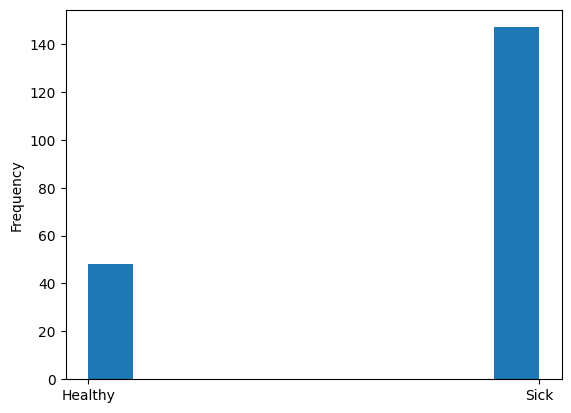

In [22]:
plt.figure()
plt.hist(data_Y)
plt.xticks([0, 1], labels=['Healthy', 'Sick'])
plt.ylabel("Frequency")
plt.show()

Plot the histograms of the first 5 attributes. 

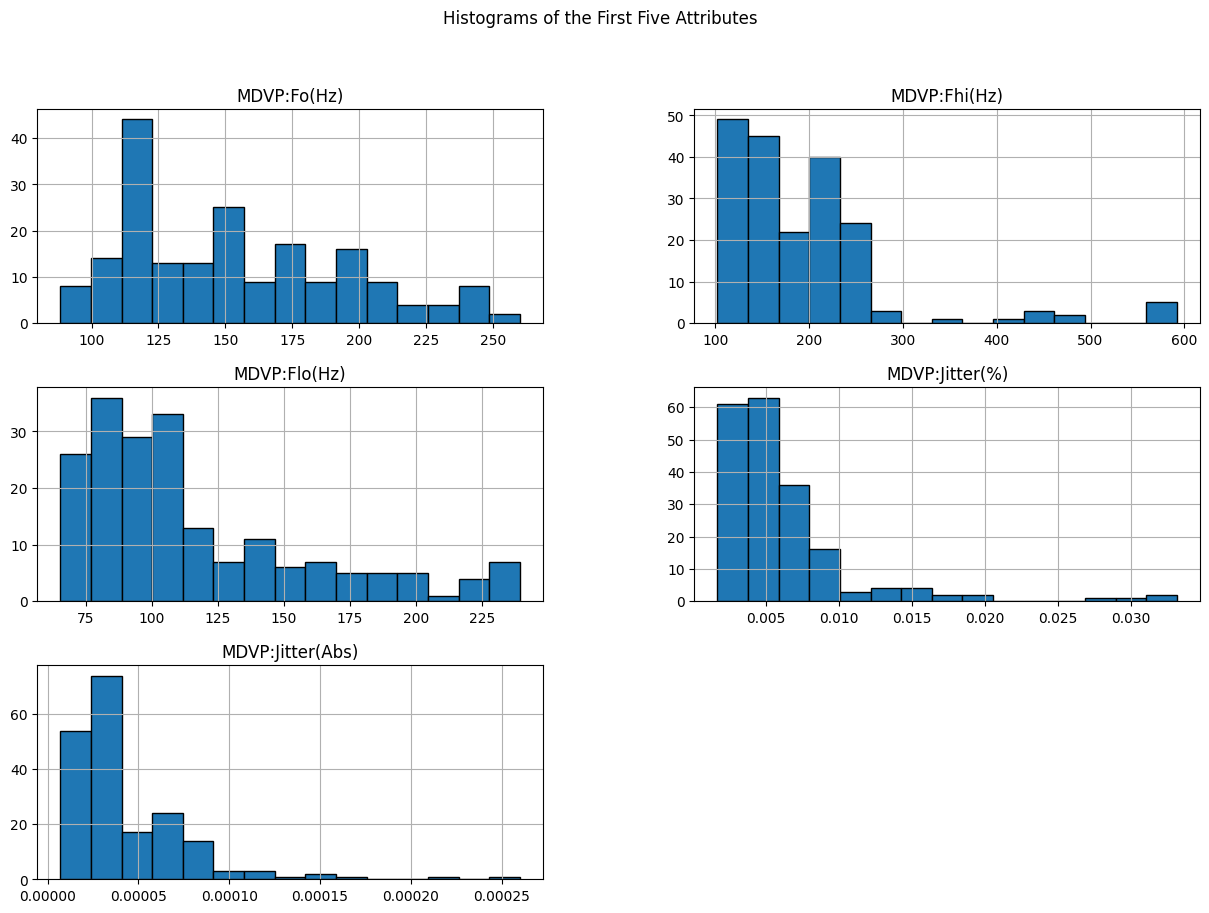

In [23]:
first_five_attributes = data_X.iloc[:, :5]
    
# Plot histograms for each of the first five attributes
first_five_attributes.hist(bins=15, edgecolor='black', figsize=(15, 10))
plt.suptitle("Histograms of the First Five Attributes")
plt.show()

# 3. Train and test set selection

#### We want to build our classifier and test it on another set of observations.

To split data into train and test sets use train_test_split method from sklearn.model_selection module (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). Use 80% of cases in train set and 20% in test set. 
Use random_state = 5 just to be sure we all have the same rows in train and test sets :)

split_data should return a tuple containing: dataframe with train set attributes, list of labels for train data, dataframe with test set attributes and a list of labels for test data.

In [24]:
def split_data(data_X, data_Y, test_percent = 20, random_state=5):
    test_size = test_percent / 100
    train_X, test_X, train_Y, test_Y = train_test_split(data_X, data_Y, test_size=test_size, random_state=random_state)

    return train_X, train_Y, test_X, test_Y
    
(train_X, train_Y, test_X, test_Y) = split_data(data_X, data_Y)
print("rows in train set: ", train_X.shape[0])
print("rows in test set:", test_X.shape[0])

rows in train set:  156
rows in test set: 39


# 4. Data standarization/normalization
#### 4.1. Use k-nn algorithm to classify the obtained test set using k=3. What is the accuracy of the classification?

Use KNeighborsClassifier class from sklearn.neighbors module. Useful methods: fit and predict. Classification accuracy can be obtained with accuracy_score method from sklearn.metrics. Function get_classification_accuracy should return the accuracy of classification of given test set on model build with train set.

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [25]:
def get_classification_accuracy(train_data_X, train_data_Y, test_data_X, test_data_Y, k = 3):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(train_data_X, train_data_Y)
    predictions = knn.predict(test_data_X)
    accuracy = metrics.accuracy_score(test_data_Y, predictions)
    
    return accuracy

get_classification_accuracy(train_X, train_Y, test_X, test_Y)

0.7692307692307693

#### 4.2. Perform some normalization or standarization of attributes. Then repeat the classification. Do the classification accuracy change?

You can use sklearn.preprocessing.StandardScaler, sklearn.preprocessing.MinMaxScaler or sklearn.preprocessing.MaxAbsScaler and their fit_transform/transform methods.

Try other standarization methods to verify the standarization procedure influence the classification accuracy.
standarize_train_and_test should return 2 dataFrames - with normalized train and normalized test sets.

In [27]:
def standarize_train_and_test(train_X, test_X, scaler_type):
    if scaler_type == "standard":
        scaler = preprocessing.StandardScaler()
    elif scaler_type == "minmax":
        scaler = preprocessing.MinMaxScaler()
    elif scaler_type == "maxabs":
        scaler = preprocessing.MaxAbsScaler()
    
    norm_train_X = scaler.fit_transform(train_X)
    norm_test_X = scaler.transform(test_X)
    
    # Convert back to DataFrames for consistency
    norm_train_X = pd.DataFrame(norm_train_X, columns=train_X.columns)
    norm_test_X = pd.DataFrame(norm_test_X, columns=test_X.columns)
    
    return norm_train_X, norm_test_X


In [28]:
norm_train_X, norm_test_X = standarize_train_and_test(train_X, test_X, 'standard')
get_classification_accuracy(norm_train_X, train_Y, norm_test_X, test_Y)

0.9743589743589743

In [29]:
norm_train_X, norm_test_X = standarize_train_and_test(train_X, test_X, 'minmax')
get_classification_accuracy(norm_train_X, train_Y, norm_test_X, test_Y)

0.9743589743589743

In [30]:
norm_train_X, norm_test_X = standarize_train_and_test(train_X, test_X, 'maxabs')
get_classification_accuracy(norm_train_X, train_Y, norm_test_X, test_Y)

0.9743589743589743

# 5. Choosing k value
Using obtained in previous exercices train set with normalization/standarization use k-nn algoritm using k from 1 to 20. Use 5-fold cross-validation within the train set to obtain the classification accuracy. Plot the obtained accuracy of the classification. Which k value seems to be the best for the given dataset?

See https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html for more info about cross validation in sklearn.

In [41]:
def find_best_k(train_X, train_Y, max_k=20, plot=True):
    k_values = range(1, max_k + 1)
    mean_accuracies = []

    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        cv_results = cross_validate(knn, train_X, train_Y, cv=5, scoring='accuracy', return_train_score=False)
        
        mean_accuracy = sum(cv_results['test_score']) / len(cv_results['test_score'])
        mean_accuracies.append(mean_accuracy)
    
    if plot:
        plt.figure(figsize=(10, 6))
        plt.plot(k_values, mean_accuracies, marker='o', linestyle='-', color='b')
        plt.xlabel("k")
        plt.ylabel("Accuracy")
        plt.xticks(k_values)
        plt.grid(True)
        plt.show()

    best_k = k_values[mean_accuracies.index(max(mean_accuracies))]
    best_accuracy = max(mean_accuracies)
    print(f"Best k value: {best_k} with accuracy: {best_accuracy:.4f}")
    
    return best_k, best_accuracy

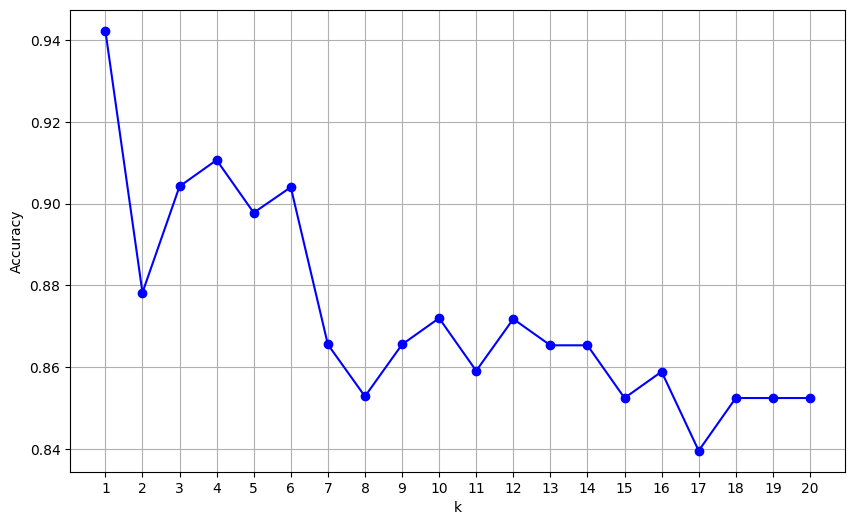

Best k value: 1 with accuracy: 0.9423


In [42]:
best_k, best_accuracy = find_best_k(norm_train_X, train_Y)

# 6. Testing classifier
Train the k-NN classifier again and test it using the obtained best k value on a test set to check the final classification accuracy. You can just call the previous written function get_classification_accuracy)

In [45]:
best_k, _ = find_best_k(train_X, train_Y, plot=False)

Best k value: 5 with accuracy: 0.8335


In [47]:
get_classification_accuracy(train_X, train_Y, test_X, test_Y, k=best_k)

0.8461538461538461

# 7. Homework
You are given a dataset containing information about 1600 red wines (winequality.csv) containing 11 attributes and assignment to one of the three wine quality classess: "poor", "medium" and "good". Perform a preprocessing of this dataset (normalization, standardization). Divide this set into the train and test sets. Choose experimentally the best value of k (using cross-validation) and perform classification using the  k-nn algoritm with the chosen k value. Write a report containing information about the used preprocessing methods, chosen train/test split method (percentage of examples in train/test sets, if shuffling or stratification used), plot of the accuracy depending of k parameter, finally chosen k and obtained classification accuracy on a test set.

**Deadline +2 weeks**
    
    

In [55]:
def read_data(path):
    data = pd.read_csv(path)
    data_X = data.drop(columns=["quality"]) 
    data_Y = data["quality"]
    
    return data_X, data_Y


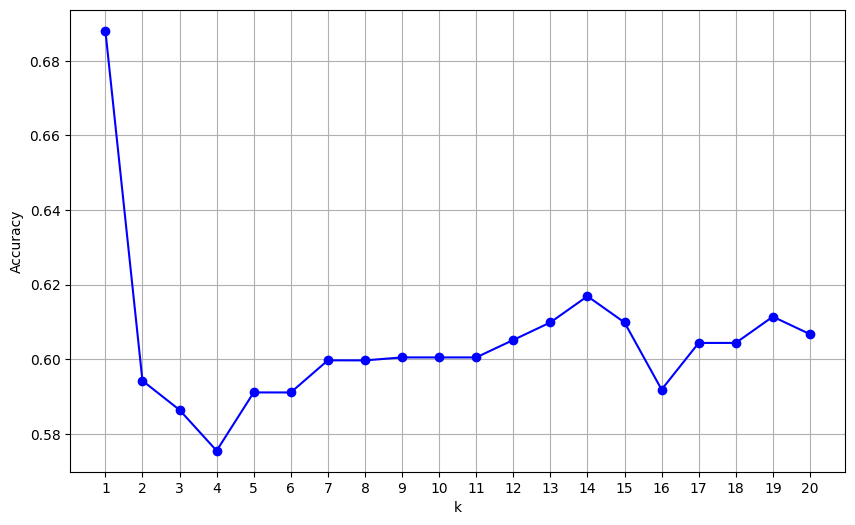

Best k value: 1 with accuracy: 0.6881
Final classification accuracy on the test set with k=1: 0.6656


In [59]:
data_X, data_Y = read_data("./data/winequality-red.csv")
train_X, train_Y, test_X, test_Y = split_data(data_X, data_Y)
norm_train_X, norm_test_X = standarize_train_and_test(train_X, test_X, scaler_type="standard")
best_k, _ = find_best_k(norm_train_X, train_Y)
final_accuracy = get_classification_accuracy(norm_train_X, train_Y, norm_test_X, test_Y, k=best_k)
print(f"Final classification accuracy on the test set with k={best_k}: {final_accuracy:.4f}")